In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
file_path = r"C:\Users\hp\Desktop\cve_anssi_enriched.csv"
df = pd.read_csv(file_path, sep=";")


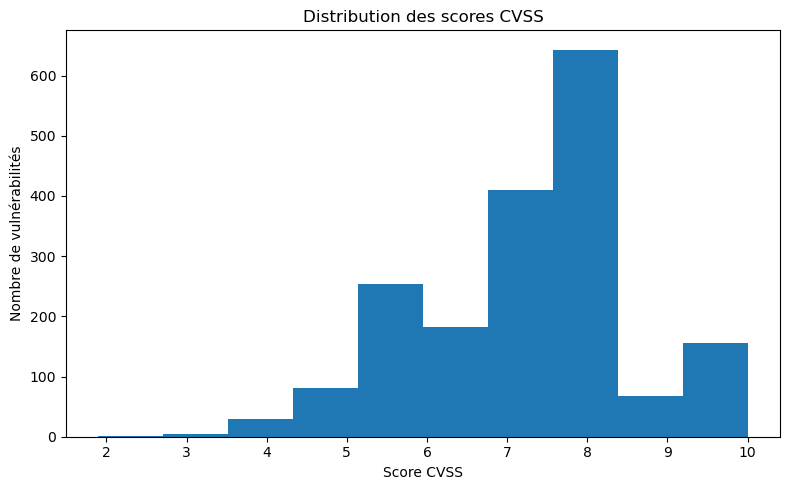

In [4]:
plt.figure(figsize=(10, 5))
plt.hist(df["Score CVSS"].dropna(), bins=10)
plt.title("Distribution des scores CVSS")
plt.xlabel("Score CVSS")
plt.ylabel("Nombre de vulnérabilités")
plt.tight_layout()
plt.show()

#CLIQUE POUR INTERPRETATION

C:\Users\hp\AppData\Local\Temp\ipykernel_12080\3430085585.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_vendors, y="Éditeur/Vendor", x="Score CVSS",


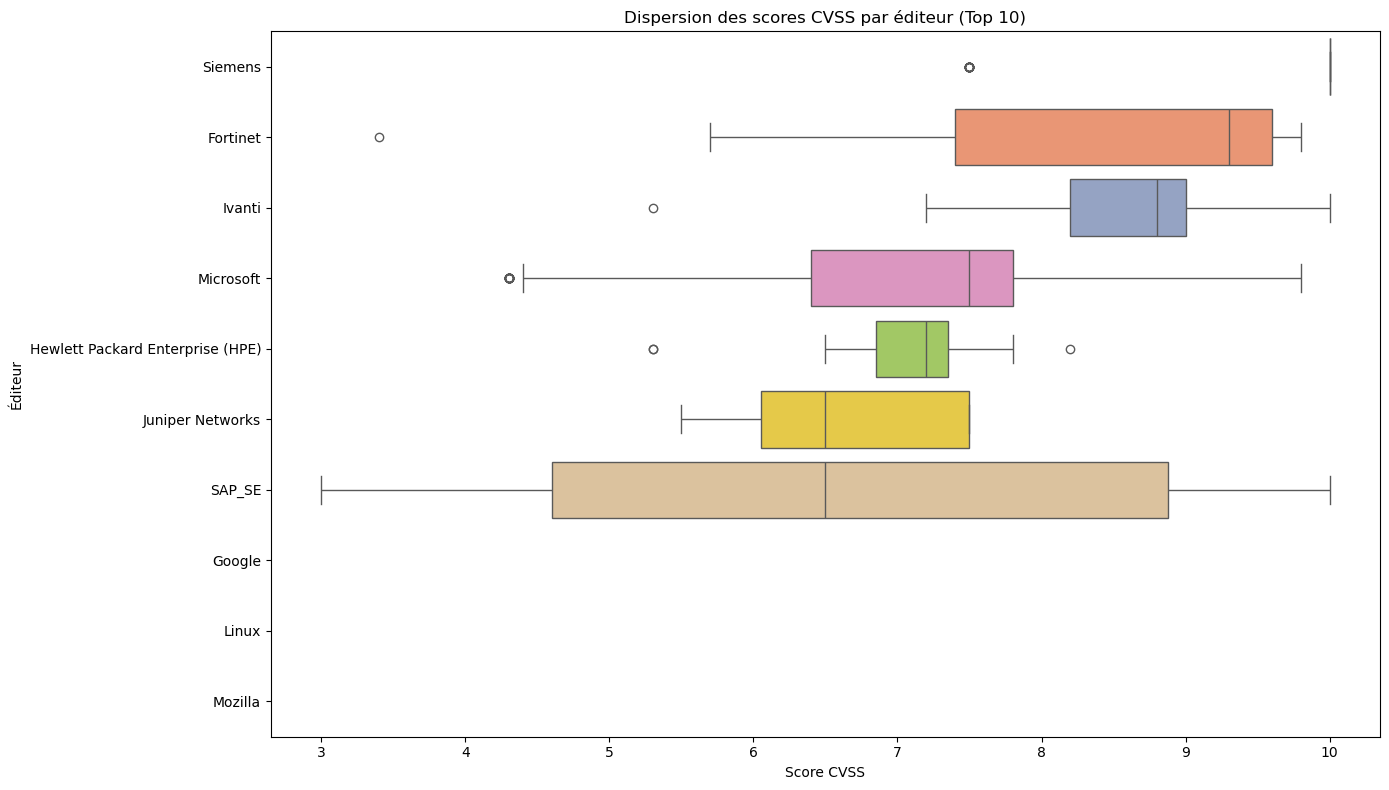

In [6]:
plt.figure(figsize=(14, 8))
top_10_vendors = df["Éditeur/Vendor"].value_counts().head(10).index
df_top_vendors = df[df["Éditeur/Vendor"].isin(top_10_vendors)].copy()
vendor_order = df_top_vendors.groupby("Éditeur/Vendor")["Score CVSS"].median().sort_values(ascending=False).index
sns.boxplot(data=df_top_vendors, y="Éditeur/Vendor", x="Score CVSS",order=vendor_order, palette="Set2")
plt.title("Dispersion des scores CVSS par éditeur (Top 10)")
plt.xlabel("Score CVSS")
plt.ylabel("Éditeur")
plt.tight_layout()
plt.show()


#CLIQUE POUR INTERPRETATION

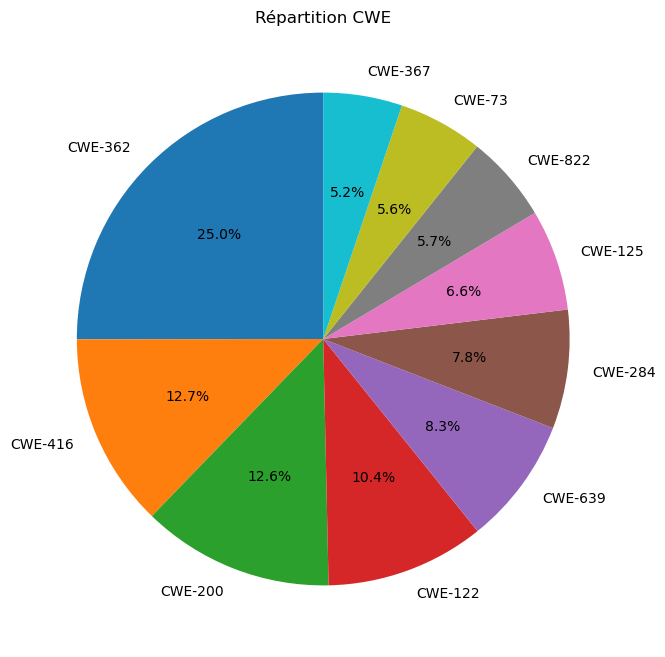

In [13]:
plt.figure(figsize=(8, 8))
df["Type CWE"].value_counts().head(10).plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Répartition CWE")
plt.ylabel("")
plt.show()

#CLIQUE POUR INTERPRETATION

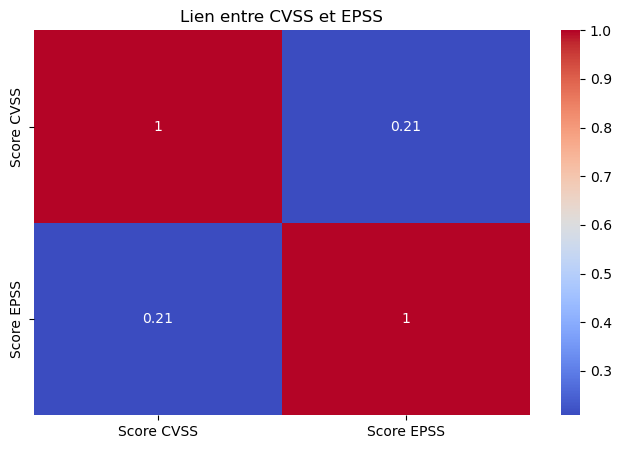

In [17]:
plt.figure(figsize=(10,5))
sns.heatmap(df[["Score CVSS","Score EPSS"]].corr(),annot=True,cmap='coolwarm')
plt.title("Lien entre CVSS et EPSS")
plt.show()

#CLIQUE

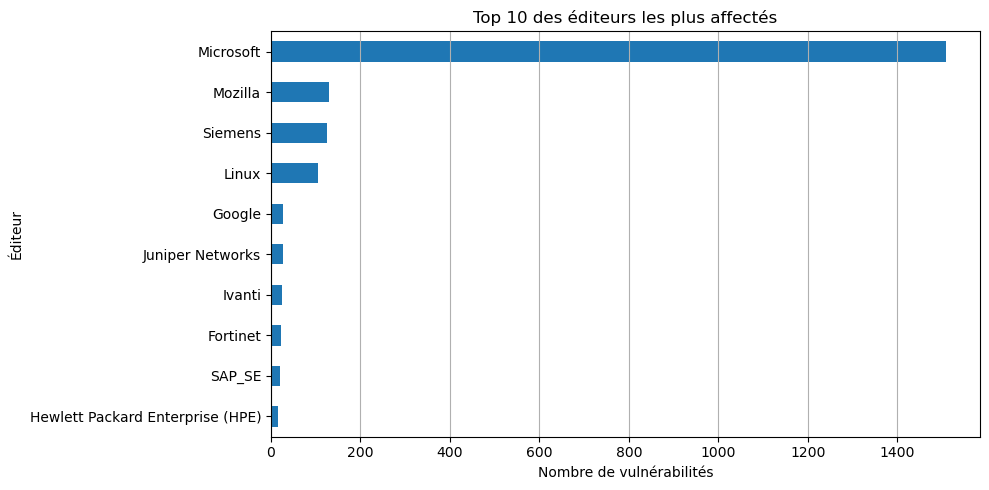

In [20]:
vendors = df["Éditeur/Vendor"].dropna().str.split(",").explode()
vendors = vendors.str.strip()
vendors = vendors[vendors != ""]
plt.figure(figsize=(10, 5))
top_vendors = vendors.value_counts().head(10)
top_vendors.plot(kind="barh")
plt.title("Top 10 des éditeurs les plus affectés")
plt.xlabel("Nombre de vulnérabilités")
plt.ylabel("Éditeur")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.grid(axis='x')
plt.show()

rnrjk

<Figure size 1400x800 with 0 Axes>

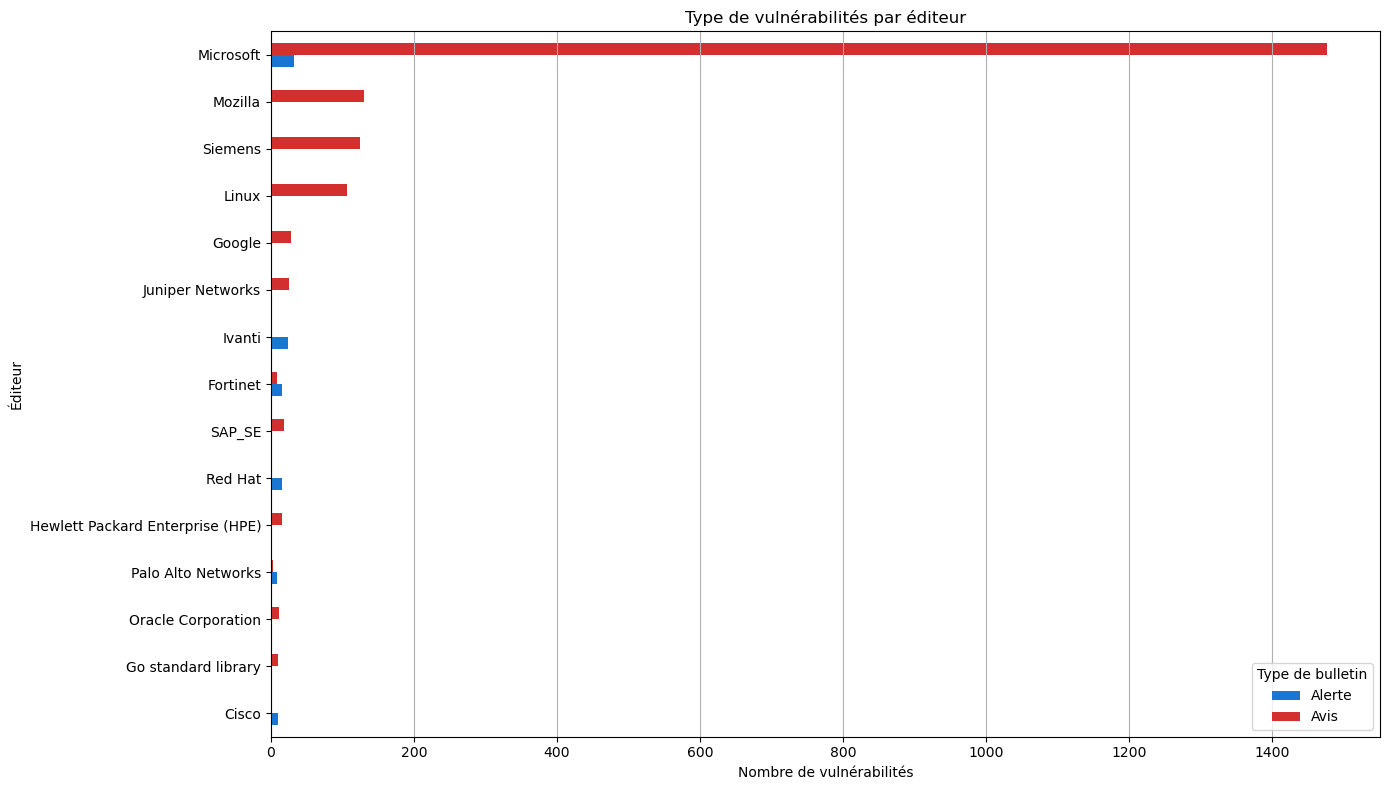

In [29]:
plt.figure(figsize=(14, 8))
pivot_data_grouped = pd.crosstab(df_top_15["Éditeur/Vendor"], df_top_15["Type de bulletin"])
pivot_data_grouped = pivot_data_grouped.reindex(pivot_data_grouped.sum(axis=1).sort_values(ascending=True).index)
pivot_data_grouped.plot(kind="barh", color=["#1976d2", "#d32f2f"],figsize=(14, 8))
plt.title("Type de vulnérabilités par éditeur")
plt.xlabel("Nombre de vulnérabilités")
plt.ylabel("Éditeur")
plt.legend(title="Type de bulletin")
plt.grid(axis='x')
plt.tight_layout()
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_12080\1031319978.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_with_cvss, x="Type de bulletin", y="Score CVSS",palette=["#1976d2", "#d32f2f"], inner="box")


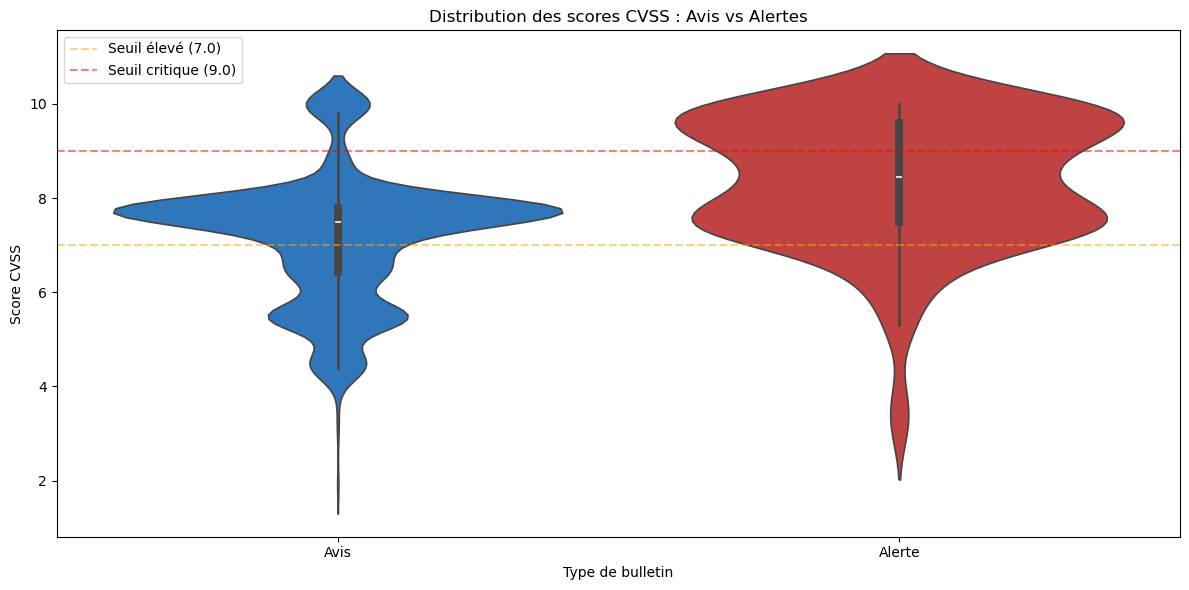

In [32]:
plt.figure(figsize=(12, 6))
df_with_cvss = df[df["Score CVSS"].notna()].copy()
sns.violinplot(data=df_with_cvss, x="Type de bulletin", y="Score CVSS",palette=["#1976d2", "#d32f2f"], inner="box")
plt.title("Distribution des scores CVSS : Avis vs Alertes")
plt.xlabel("Type de bulletin")
plt.ylabel("Score CVSS")
plt.axhline(7, color='orange', linestyle='--', alpha=0.5, label='Seuil élevé (7.0)')
plt.axhline(9, color='red', linestyle='--', alpha=0.5, label='Seuil critique (9.0)')
plt.legend()
plt.tight_layout()
plt.show()


az

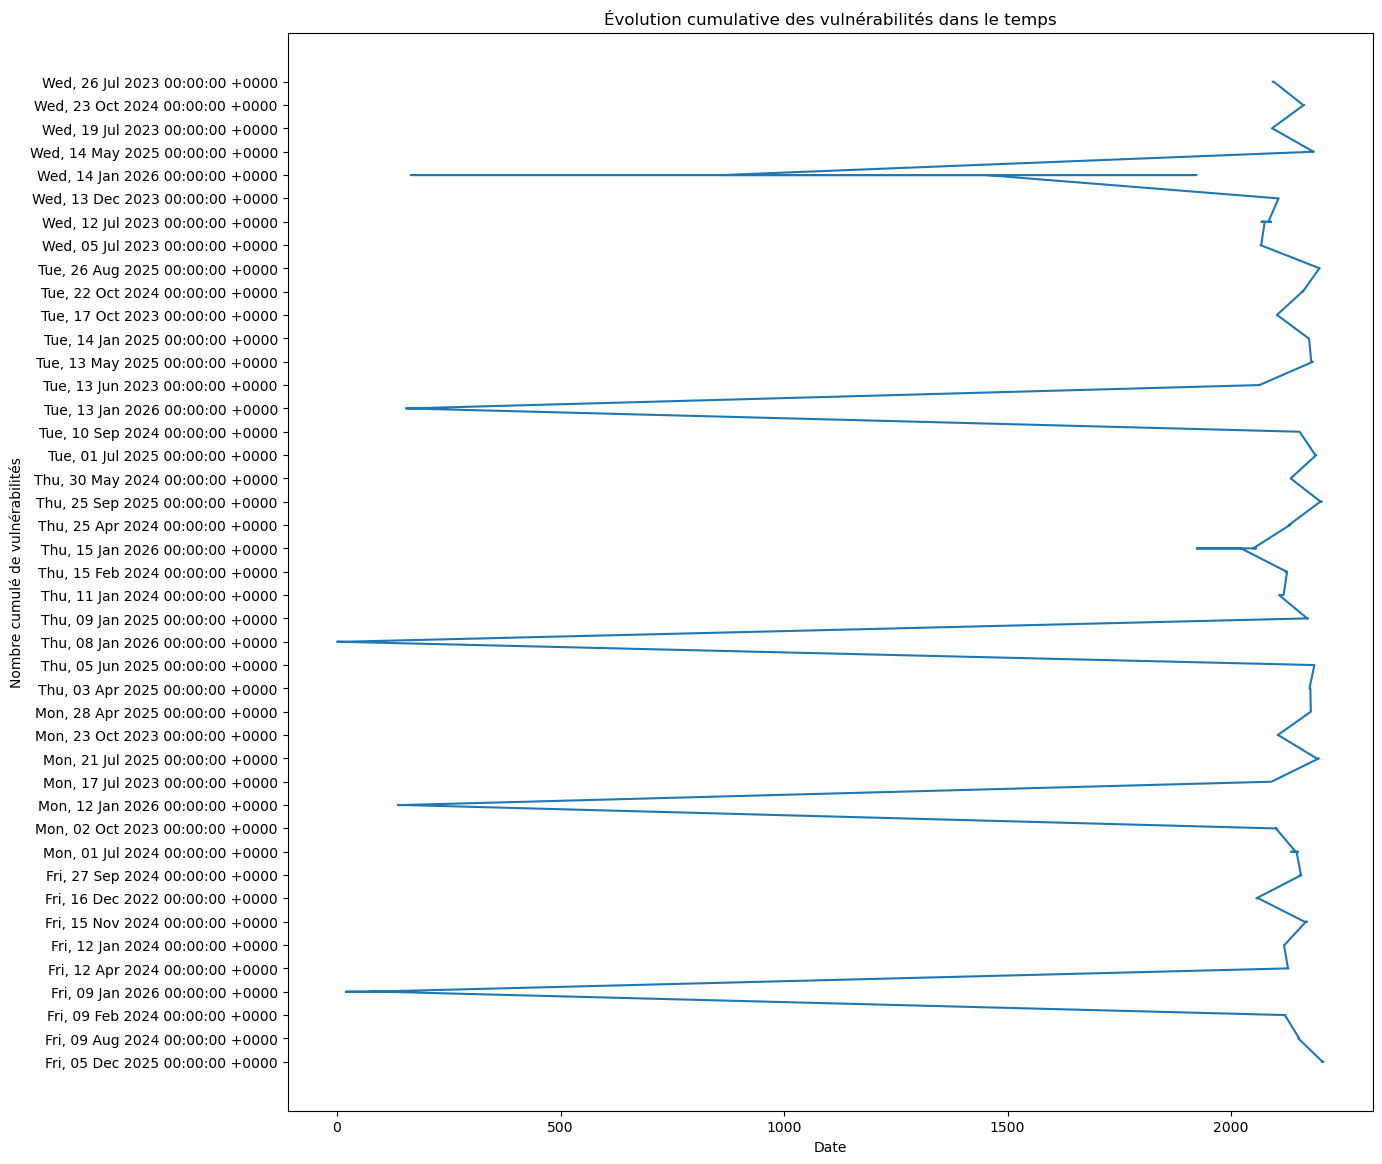

In [38]:
df_time = df.dropna(subset=["Date de publication"]).sort_values("Date de publication")
plt.figure(figsize=(14, 14))
plt.plot(df_time["Date de publication"])
plt.title("Évolution du nombre des vulnérabilités dans le temps")
plt.xlabel("Date")
plt.ylabel("Nombre cumulé de vulnérabilités")
plt.show()

f

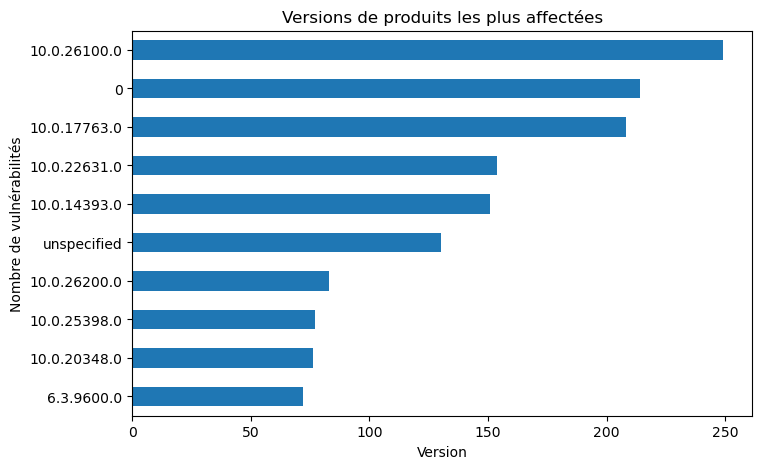

In [46]:
versions = df["Versions affectées"].dropna().str.split(",").explode()
versions = versions.str.strip()
versions = versions[versions != ""]
plt.figure(figsize=(8, 5))
versions.value_counts().head(10).plot(kind="barh")
plt.title("Versions de produits les plus affectées")
plt.xlabel("Version")
plt.ylabel("Nombre de vulnérabilités")
plt.gca().invert_yaxis()
plt.show()

f

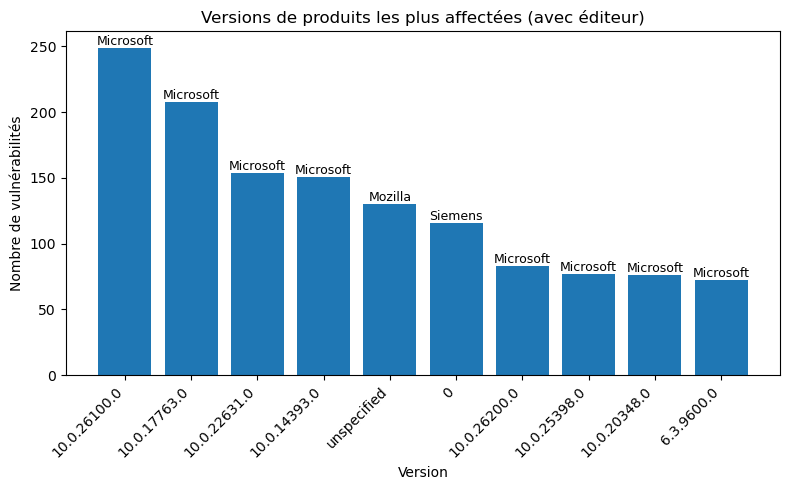

In [49]:
temp = df[["Versions affectées", "Éditeur/Vendor"]].dropna().reset_index(drop=True)
temp = temp.assign(versions = temp["Versions affectées"].str.split(",")).explode("versions")
temp["versions"] = temp["versions"].str.strip()
temp = temp[temp["versions"] != ""]
top = (temp.groupby(["versions", "Éditeur/Vendor"]).size().reset_index(name="count").sort_values("count", ascending=False).head(10))
plt.figure(figsize=(8, 5))
plt.bar(top["versions"], top["count"])
for i, ed in enumerate(top["Éditeur/Vendor"]):
    plt.text(i, top["count"].iloc[i], ed, ha='center', va='bottom', fontsize=9)
plt.title("Versions de produits les plus affectées (avec éditeur)")
plt.xlabel("Version")
plt.ylabel("Nombre de vulnérabilités")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

f

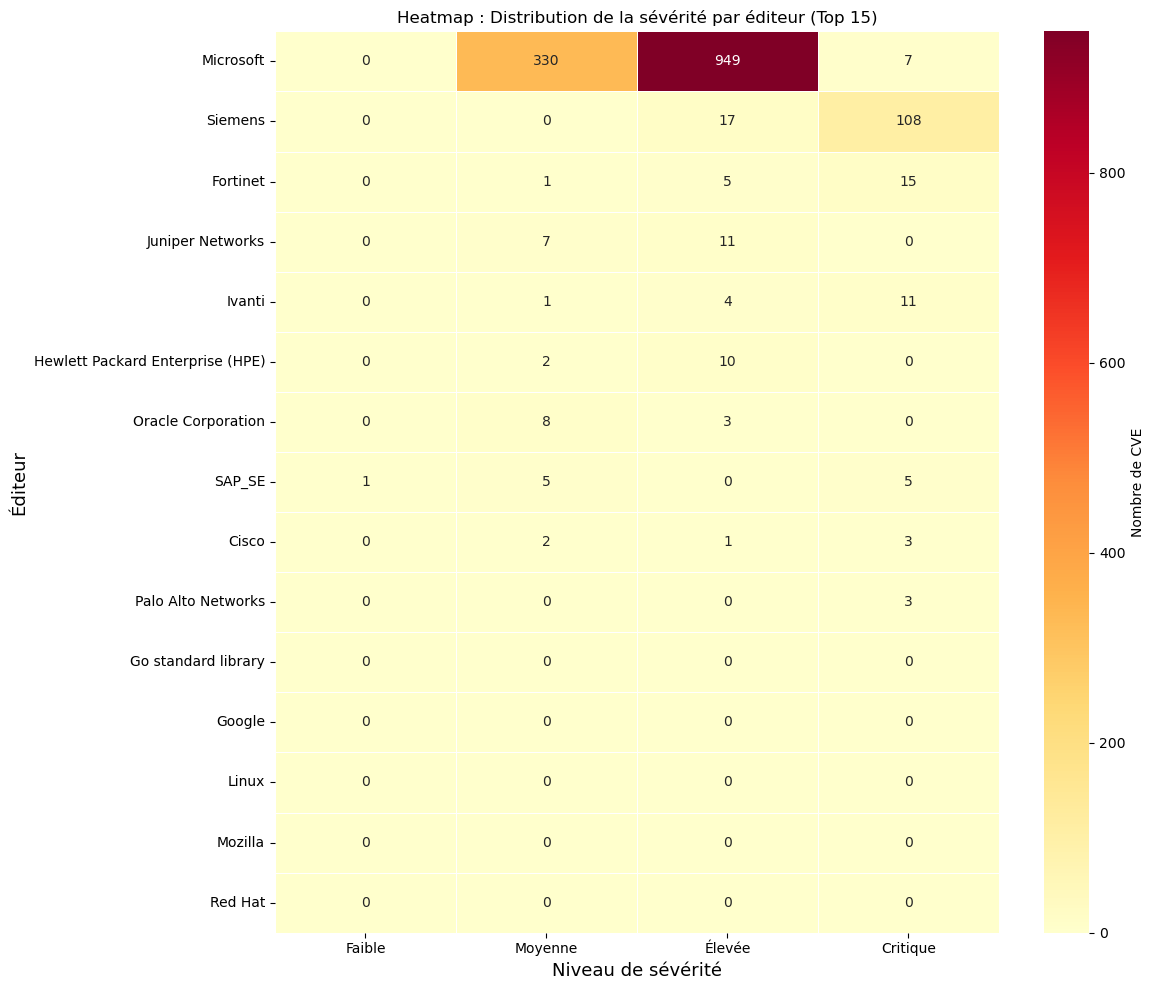

In [52]:
top_15_vendors = df["Éditeur/Vendor"].value_counts().head(15).index
df_top_vendors_heat = df[df["Éditeur/Vendor"].isin(top_15_vendors)].copy()
severity_order = ["Faible", "Moyenne", "Élevée", "Critique"]
heatmap_data = pd.crosstab(df_top_vendors_heat["Éditeur/Vendor"], df_top_vendors_heat["Base Severity"])
heatmap_data = heatmap_data.reindex(columns=[s for s in severity_order if s in heatmap_data.columns])
heatmap_data = heatmap_data.loc[heatmap_data.sum(axis=1).sort_values(ascending=False).index]
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlOrRd", cbar_kws={'label': 'Nombre de CVE'}, linewidths=0.5)
plt.title("Heatmap : Distribution de la sévérité par éditeur (Top 15)")
plt.xlabel("Niveau de sévérité", fontsize=13)
plt.ylabel("Éditeur", fontsize=13)
plt.tight_layout()
plt.show()

f

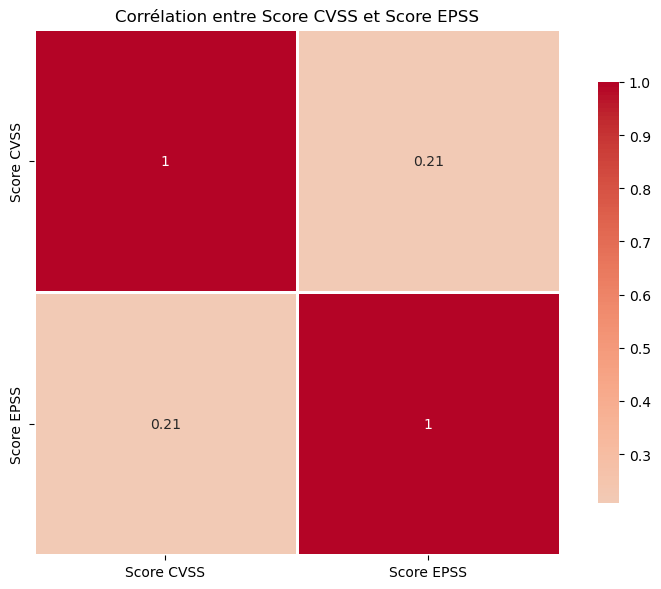

In [55]:
df_scores = df[["Score CVSS", "Score EPSS"]].dropna()
plt.figure(figsize=(8, 6))
correlation_matrix = df_scores.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title("Corrélation entre Score CVSS et Score EPSS", )
plt.tight_layout()
plt.show()

f